# BAR Economy Waterfill Solver Analysis

This notebook visualizes the **waterfill resource sharing algorithm** that balances resources within team alliances.

## How the Algorithm Works

1. **Share Cursor**: Each team sets a threshold (`storage × shareSlider`) - resources above this get shared
2. **Lift**: A common "water level lift" is computed to balance supply = demand across the alliance  
3. **Target**: Each team's target = `min(shareCursor + lift, storage)`
4. **Flow**: Resources flow from teams above target (senders) to teams below target (receivers)
5. **Tax**: Transfers above the tax-free threshold are taxed (resources destroyed)

**Key Invariant**: `Σ Received = Σ Sent - Tax`

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
from plotnine import *
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import time
import warnings

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

DB_PATH = 'audit_logs.db'

METAL_COLOR = '#4FC3F7'
ENERGY_COLOR = '#FFD54F'
SENDER_COLOR = '#EF5350'
RECEIVER_COLOR = '#66BB6A'
NEUTRAL_COLOR = '#78909C'
TAX_COLOR = '#AB47BC'

def get_conn():
    return sqlite3.connect(DB_PATH, timeout=10)

def query_df(sql, params=None):
    conn = get_conn()
    try:
        return pd.read_sql_query(sql, conn, params=params)
    finally:
        conn.close()

print("✓ Libraries loaded | Dark theme enabled")

✓ Libraries loaded | Dark theme enabled


## 1. Data Summary & Frame Selection

First, let's see what data is available and pick a frame to analyze:

In [2]:
def get_data_summary():
    tables = ['eco_frame_start', 'eco_team_input', 'eco_team_output', 'eco_team_waterfill', 'eco_group_lift', 'eco_transfer', 'solver_audit']
    rows = []
    for t in tables:
        try:
            df = query_df(f"SELECT COUNT(*) as cnt, MIN(frame) as min_f, MAX(frame) as max_f FROM {t}")
            rows.append({'Table': t, 'Rows': df['cnt'].iloc[0], 'Min Frame': df['min_f'].iloc[0], 'Max Frame': df['max_f'].iloc[0]})
        except:
            rows.append({'Table': t, 'Rows': 0, 'Min Frame': None, 'Max Frame': None})
    return pd.DataFrame(rows)

summary = get_data_summary()
display(HTML("<h3>📊 Available Data</h3>"))
display(summary)

max_frame = summary[summary['Table'] == 'eco_team_waterfill']['Max Frame'].iloc[0]
if max_frame:
    print(f"\n🎯 Latest frame with waterfill data: {int(max_frame)}")
else:
    print("\n⚠️  No waterfill data found. Run a game with economy audit enabled!")

,Table,Rows,Min Frame,Max Frame
0,eco_frame_start,731,0,21930
1,eco_team_input,7303,0,21930
2,eco_team_output,7290,0,21900
3,eco_team_waterfill,3065,12750,21930
4,eco_group_lift,4381,0,21930
5,eco_transfer,298,12750,21570
6,solver_audit,5832,0,21900



🎯 Latest frame with waterfill data: 21930


📍 Analyzing frame: 21930


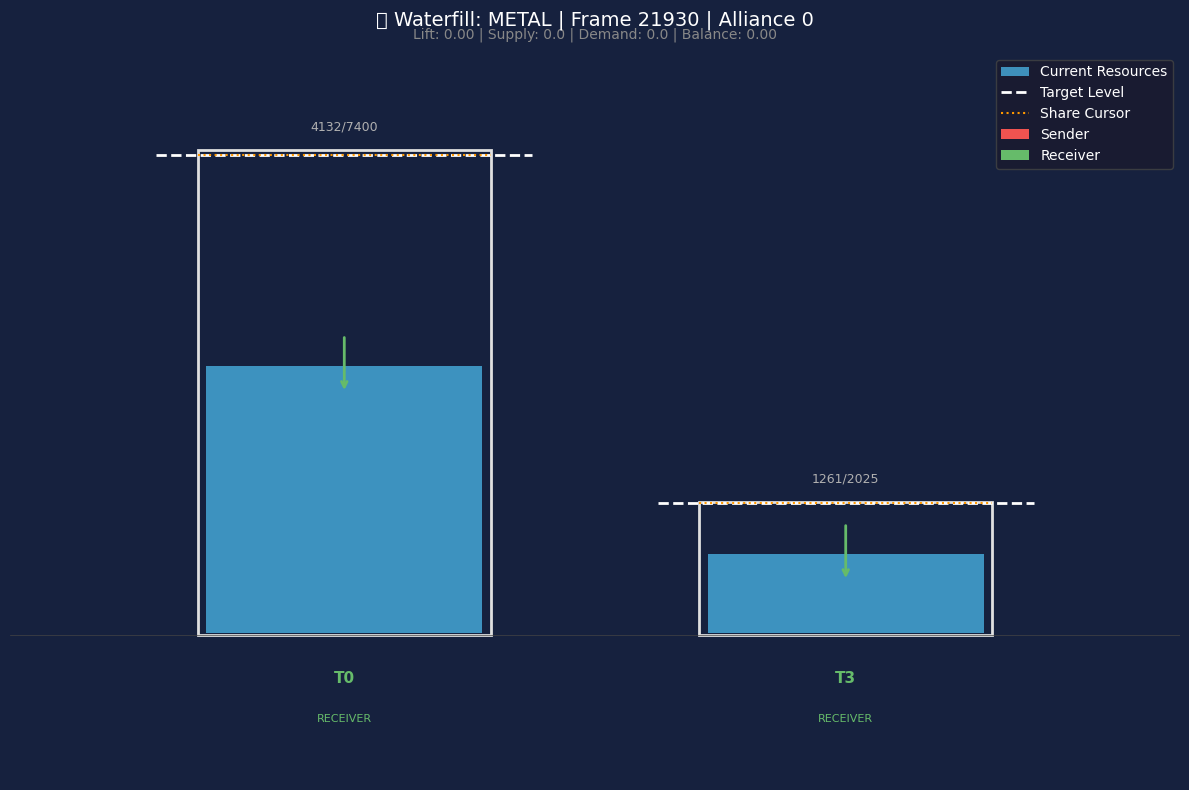

In [3]:
## 2. Waterfill Tank Diagram

def draw_waterfill_diagram(frame, resource='metal', ally_team=0):
    """Draw a beautiful tank diagram showing the waterfill algorithm in action."""
    
    wf = query_df("""
        SELECT * FROM eco_team_waterfill 
        WHERE frame = ? AND resource = ? AND ally_team = ?
        ORDER BY team_id
    """, (frame, resource, ally_team))
    
    inp = query_df("""
        SELECT team_id, storage, share_cursor FROM eco_team_input
        WHERE frame = ? AND resource = ? AND ally_team = ?
    """, (frame, resource, ally_team))
    
    lift_df = query_df("""
        SELECT lift, total_supply, total_demand FROM eco_group_lift
        WHERE frame = ? AND resource = ? AND ally_team = ?
    """, (frame, resource, ally_team))
    
    if wf.empty:
        print(f"No waterfill data for frame {frame}, {resource}, ally {ally_team}")
        return None
    
    wf = wf.merge(inp, on='team_id', how='left')
    n_teams = len(wf)
    lift = lift_df['lift'].iloc[0] if not lift_df.empty else 0
    supply = lift_df['total_supply'].iloc[0] if not lift_df.empty else 0
    demand = lift_df['total_demand'].iloc[0] if not lift_df.empty else 0
    
    fig, ax = plt.subplots(figsize=(max(12, n_teams * 2), 8))
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#16213e')
    
    max_storage = wf['storage'].max() if not wf.empty else 1000
    tank_width = 0.7
    spacing = 1.2
    resource_color = METAL_COLOR if resource == 'metal' else ENERGY_COLOR
    
    for i, row in wf.iterrows():
        x = i * spacing
        storage = row['storage']
        current = row['current']
        target = row['target']
        share_cursor = row['share_cursor'] if pd.notna(row['share_cursor']) else 0
        role = row['role']
        
        height_scale = storage / max_storage if max_storage > 0 else 1
        tank_height = 5 * height_scale
        
        tank = Rectangle((x - tank_width/2, 0), tank_width, tank_height, 
                         fill=False, edgecolor='#e0e0e0', linewidth=2)
        ax.add_patch(tank)
        
        fill_height = (current / storage * tank_height) if storage > 0 else 0
        fill = Rectangle((x - tank_width/2 + 0.02, 0.02), tank_width - 0.04, fill_height - 0.04,
                         facecolor=resource_color, alpha=0.7)
        ax.add_patch(fill)
        
        target_y = (target / storage * tank_height) if storage > 0 else 0
        ax.hlines(target_y, x - tank_width/2 - 0.1, x + tank_width/2 + 0.1, 
                 colors='#ffffff', linestyles='--', linewidth=2, label='Target' if i == 0 else '')
        
        cursor_y = (share_cursor / storage * tank_height) if storage > 0 else 0
        ax.hlines(cursor_y, x - tank_width/2, x + tank_width/2,
                 colors='#ff9800', linestyles=':', linewidth=1.5)
        
        role_colors = {'sender': SENDER_COLOR, 'receiver': RECEIVER_COLOR, 'neutral': NEUTRAL_COLOR}
        role_color = role_colors.get(role, NEUTRAL_COLOR)
        ax.text(x, -0.5, f"T{int(row['team_id'])}", ha='center', fontsize=11, 
               color=role_color, fontweight='bold')
        ax.text(x, -0.9, role.upper(), ha='center', fontsize=8, color=role_color)
        
        if role == 'sender':
            arrow_y = fill_height
            ax.annotate('', xy=(x, arrow_y + 0.3), xytext=(x, arrow_y - 0.3),
                       arrowprops=dict(arrowstyle='->', color=SENDER_COLOR, lw=2))
        elif role == 'receiver':
            arrow_y = fill_height
            ax.annotate('', xy=(x, arrow_y - 0.3), xytext=(x, arrow_y + 0.3),
                       arrowprops=dict(arrowstyle='->', color=RECEIVER_COLOR, lw=2))
        
        ax.text(x, tank_height + 0.2, f"{current:.0f}/{storage:.0f}", 
               ha='center', fontsize=9, color='#b0b0b0')
    
    ax.axhline(y=0, color='#444', linewidth=0.5)
    
    title = f"🌊 Waterfill: {resource.upper()} | Frame {frame} | Alliance {ally_team}"
    ax.set_title(title, fontsize=14, color='white', pad=20)
    
    subtitle = f"Lift: {lift:.2f} | Supply: {supply:.1f} | Demand: {demand:.1f} | Balance: {supply - demand:.2f}"
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha='center', fontsize=10, color='#888')
    
    legend_elements = [
        mpatches.Patch(facecolor=resource_color, alpha=0.7, label='Current Resources'),
        plt.Line2D([0], [0], color='white', linestyle='--', linewidth=2, label='Target Level'),
        plt.Line2D([0], [0], color='#ff9800', linestyle=':', linewidth=1.5, label='Share Cursor'),
        mpatches.Patch(facecolor=SENDER_COLOR, label='Sender'),
        mpatches.Patch(facecolor=RECEIVER_COLOR, label='Receiver'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', facecolor='#1a1a2e', 
             edgecolor='#444', labelcolor='white')
    
    ax.set_xlim(-0.8, n_teams * spacing - 0.4)
    ax.set_ylim(-1.5, max_storage / max_storage * 5 + 1)
    ax.axis('off')
    
    plt.tight_layout()
    return fig

ANALYSIS_FRAME = None
try:
    frames = query_df("SELECT DISTINCT frame FROM eco_team_waterfill ORDER BY frame DESC LIMIT 1")
    if not frames.empty:
        ANALYSIS_FRAME = int(frames['frame'].iloc[0])
        print(f"📍 Analyzing frame: {ANALYSIS_FRAME}")
        fig = draw_waterfill_diagram(ANALYSIS_FRAME, 'metal', 0)
        if fig:
            plt.show()
except Exception as e:
    print(f"Could not draw waterfill diagram: {e}")

In [4]:
## 3. Conservation of Resources Check

def verify_conservation(frame, resource='metal'):
    """Verify the key invariant: Total Received = Total Sent - Tax"""
    
    output = query_df("""
        SELECT team_id, sent, received FROM eco_team_output
        WHERE frame = ? AND resource = ?
    """, (frame, resource))
    
    frame_config = query_df("""
        SELECT tax_rate FROM eco_frame_start WHERE frame = ?
    """, (frame,))
    
    if output.empty:
        return None
    
    total_sent = output['sent'].sum()
    total_received = output['received'].sum()
    tax_rate = frame_config['tax_rate'].iloc[0] if not frame_config.empty else 0
    
    transfers = query_df("""
        SELECT SUM(amount) as total_amount, SUM(untaxed) as total_untaxed, 
               SUM(taxed) as total_taxed, SUM(amount - untaxed - taxed) as tax_lost
        FROM eco_transfer WHERE frame = ? AND resource = ?
    """, (frame, resource))
    
    tax_collected = total_sent - total_received
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.patch.set_facecolor('#16213e')
    for ax in axes:
        ax.set_facecolor('#1a1a2e')
    
    resource_color = METAL_COLOR if resource == 'metal' else ENERGY_COLOR
    
    bars = axes[0].bar(['Sent', 'Received', 'Tax'], [total_sent, total_received, tax_collected],
                       color=[SENDER_COLOR, RECEIVER_COLOR, TAX_COLOR])
    axes[0].set_title('Resource Flow Summary', color='white', fontsize=12)
    axes[0].set_ylabel('Amount', color='white')
    axes[0].tick_params(colors='white')
    for bar, val in zip(bars, [total_sent, total_received, tax_collected]):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{val:.1f}', ha='center', color='white', fontsize=10)
    
    balance_error = abs(total_sent - total_received - tax_collected)
    colors = ['#66BB6A' if balance_error < 0.01 else '#EF5350']
    axes[1].bar(['Balance Check'], [balance_error], color=colors)
    axes[1].axhline(y=0.01, color='#ff9800', linestyle='--', label='Tolerance')
    axes[1].set_title('Conservation Verification', color='white', fontsize=12)
    axes[1].set_ylabel('|Sent - Received - Tax|', color='white')
    axes[1].tick_params(colors='white')
    status = "✓ PASS" if balance_error < 0.01 else "✗ FAIL"
    axes[1].text(0, balance_error + 0.001, status, ha='center', 
                color='#66BB6A' if balance_error < 0.01 else '#EF5350', fontsize=14, fontweight='bold')
    
    team_data = output.copy()
    team_data['net_flow'] = team_data['received'] - team_data['sent']
    colors = [RECEIVER_COLOR if x >= 0 else SENDER_COLOR for x in team_data['net_flow']]
    axes[2].bar(team_data['team_id'].astype(str), team_data['net_flow'], color=colors)
    axes[2].axhline(y=0, color='white', linewidth=0.5)
    axes[2].set_title('Net Flow per Team', color='white', fontsize=12)
    axes[2].set_xlabel('Team ID', color='white')
    axes[2].set_ylabel('Net Flow (+receive, -send)', color='white')
    axes[2].tick_params(colors='white')
    
    fig.suptitle(f'💰 Conservation Check: {resource.upper()} | Frame {frame} | Tax Rate: {tax_rate*100:.1f}%', 
                color='white', fontsize=14)
    plt.tight_layout()
    return fig

if ANALYSIS_FRAME:
    print("--- METAL ---")
    fig = verify_conservation(ANALYSIS_FRAME, 'metal')
    if fig: plt.show()
    print("\n--- ENERGY ---")
    fig = verify_conservation(ANALYSIS_FRAME, 'energy')
    if fig: plt.show()

--- METAL ---

--- ENERGY ---


## 4. Time Series Analysis

These plots show solver behavior over time:

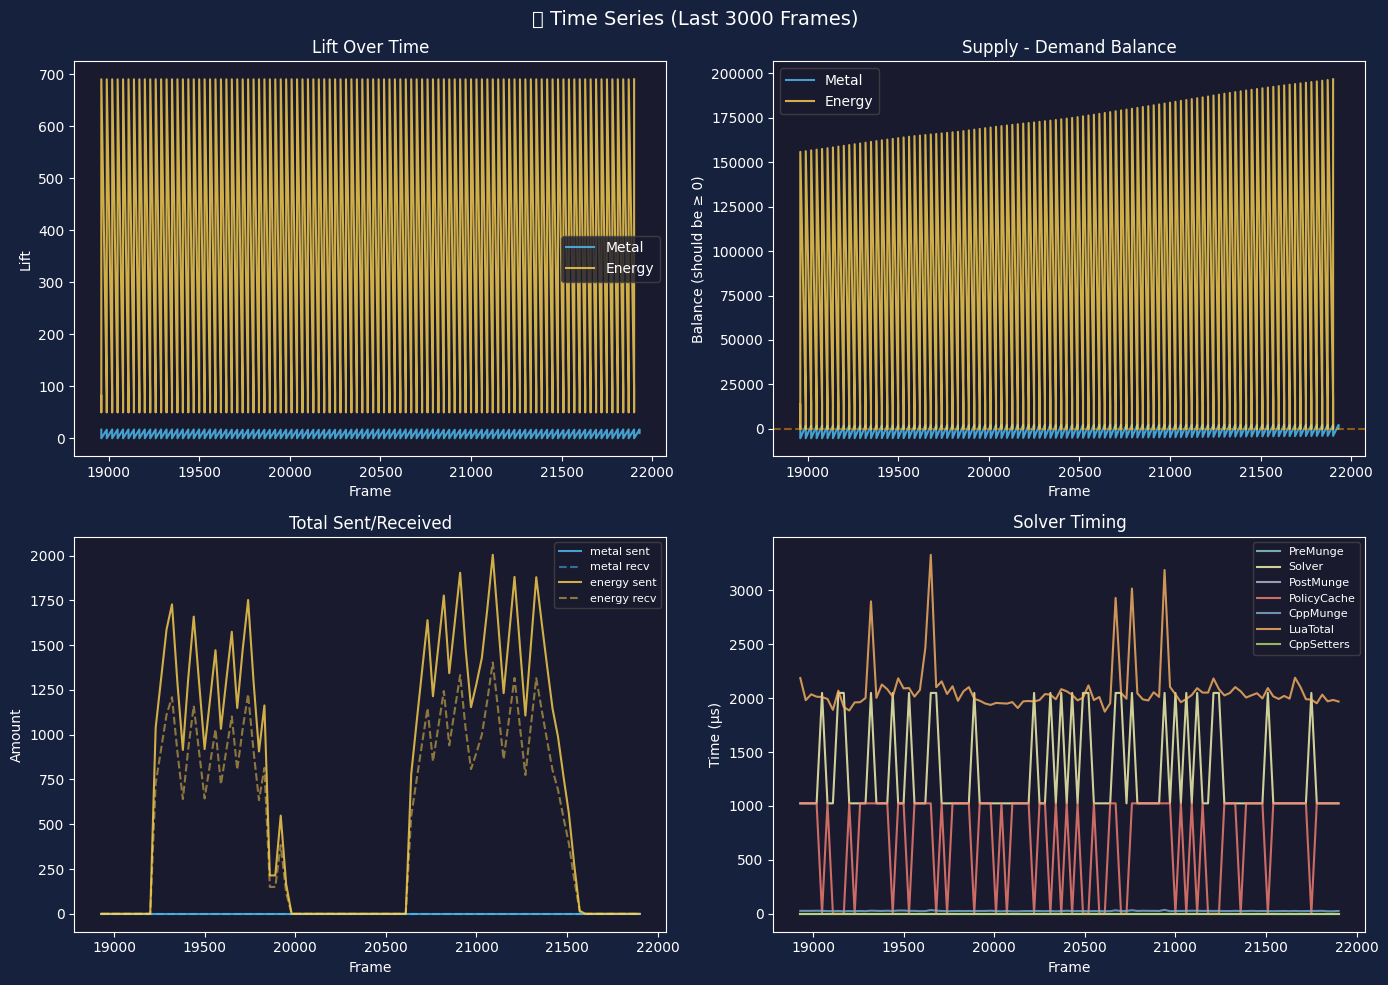

In [5]:
def plot_time_series(limit=3000):
    """Plot lift, supply/demand, and transfers over time."""
    
    lift_df = query_df(f"""
        SELECT frame, resource, lift, total_supply, total_demand 
        FROM eco_group_lift 
        WHERE frame > (SELECT MAX(frame) FROM eco_group_lift) - {limit}
        ORDER BY frame
    """)
    
    if lift_df.empty:
        print("No lift data available")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.patch.set_facecolor('#16213e')
    for ax in axes.flatten():
        ax.set_facecolor('#1a1a2e')
        ax.tick_params(colors='white')
    
    for resource, color in [('metal', METAL_COLOR), ('energy', ENERGY_COLOR)]:
        rdf = lift_df[lift_df['resource'] == resource]
        if not rdf.empty:
            axes[0, 0].plot(rdf['frame'], rdf['lift'], label=resource.capitalize(), color=color, alpha=0.8)
    axes[0, 0].set_title('Lift Over Time', color='white')
    axes[0, 0].set_xlabel('Frame', color='white')
    axes[0, 0].set_ylabel('Lift', color='white')
    axes[0, 0].legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
    
    for resource, color in [('metal', METAL_COLOR), ('energy', ENERGY_COLOR)]:
        rdf = lift_df[lift_df['resource'] == resource]
        if not rdf.empty:
            rdf['balance'] = rdf['total_supply'] - rdf['total_demand']
            axes[0, 1].plot(rdf['frame'], rdf['balance'], label=resource.capitalize(), color=color, alpha=0.8)
    axes[0, 1].axhline(y=0, color='#ff9800', linestyle='--', alpha=0.5)
    axes[0, 1].set_title('Supply - Demand Balance', color='white')
    axes[0, 1].set_xlabel('Frame', color='white')
    axes[0, 1].set_ylabel('Balance (should be ≥ 0)', color='white')
    axes[0, 1].legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
    
    output_df = query_df(f"""
        SELECT frame, resource, SUM(sent) as total_sent, SUM(received) as total_received
        FROM eco_team_output
        WHERE frame > (SELECT MAX(frame) FROM eco_team_output) - {limit}
        GROUP BY frame, resource
        ORDER BY frame
    """)
    
    if not output_df.empty:
        for resource, color in [('metal', METAL_COLOR), ('energy', ENERGY_COLOR)]:
            rdf = output_df[output_df['resource'] == resource]
            if not rdf.empty:
                axes[1, 0].plot(rdf['frame'], rdf['total_sent'], label=f'{resource} sent', 
                              color=color, alpha=0.8, linestyle='-')
                axes[1, 0].plot(rdf['frame'], rdf['total_received'], label=f'{resource} recv', 
                              color=color, alpha=0.5, linestyle='--')
    axes[1, 0].set_title('Total Sent/Received', color='white')
    axes[1, 0].set_xlabel('Frame', color='white')
    axes[1, 0].set_ylabel('Amount', color='white')
    axes[1, 0].legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=8)
    
    solver_df = query_df(f"""
        SELECT frame, metric, time_us FROM solver_audit
        WHERE frame > (SELECT MAX(frame) FROM solver_audit) - {limit}
        AND metric != 'Overall'
        ORDER BY frame
    """)
    
    if not solver_df.empty:
        metrics = solver_df['metric'].unique()
        colors = plt.cm.viridis(np.linspace(0, 1, len(metrics)))
        for metric, color in zip(metrics, colors):
            mdf = solver_df[solver_df['metric'] == metric]
            axes[1, 1].plot(mdf['frame'], mdf['time_us'], label=metric, alpha=0.8)
    axes[1, 1].set_title('Solver Timing', color='white')
    axes[1, 1].set_xlabel('Frame', color='white')
    axes[1, 1].set_ylabel('Time (μs)', color='white')
    axes[1, 1].legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=8)
    
    fig.suptitle(f'📈 Time Series (Last {limit} Frames)', color='white', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_time_series()

## 5. Transfer Flow Matrix

Who sent resources to whom? This shows the flow of resources between teams:


In [6]:
def plot_transfer_matrix(frame, resource='metal'):
    """Show transfer flow as a heatmap matrix."""
    
    transfers = query_df("""
        SELECT sender_team_id, receiver_team_id, SUM(amount) as total_amount
        FROM eco_transfer
        WHERE frame = ? AND resource = ?
        GROUP BY sender_team_id, receiver_team_id
    """, (frame, resource))
    
    if transfers.empty:
        print(f"No transfer data for frame {frame}, {resource}")
        return None
    
    all_teams = sorted(set(transfers['sender_team_id'].tolist() + transfers['receiver_team_id'].tolist()))
    n = len(all_teams)
    team_idx = {t: i for i, t in enumerate(all_teams)}
    
    matrix = np.zeros((n, n))
    for _, row in transfers.iterrows():
        i = team_idx[row['sender_team_id']]
        j = team_idx[row['receiver_team_id']]
        matrix[i, j] = row['total_amount']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('#16213e')
    ax.set_facecolor('#1a1a2e')
    
    cmap = LinearSegmentedColormap.from_list('flow', ['#1a1a2e', METAL_COLOR if resource == 'metal' else ENERGY_COLOR])
    im = ax.imshow(matrix, cmap=cmap, aspect='equal')
    
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f'T{t}' for t in all_teams], color='white')
    ax.set_yticklabels([f'T{t}' for t in all_teams], color='white')
    ax.set_xlabel('Receiver', color='white')
    ax.set_ylabel('Sender', color='white')
    
    for i in range(n):
        for j in range(n):
            if matrix[i, j] > 0:
                ax.text(j, i, f'{matrix[i, j]:.0f}', ha='center', va='center', 
                       color='white' if matrix[i, j] > matrix.max()/2 else '#888', fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.outline.set_edgecolor('white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
    
    ax.set_title(f'🔄 Transfer Matrix: {resource.upper()} | Frame {frame}', color='white', fontsize=12)
    plt.tight_layout()
    return fig

if ANALYSIS_FRAME:
    fig = plot_transfer_matrix(ANALYSIS_FRAME, 'metal')
    if fig: plt.show()


No transfer data for frame 21930, metal


## 6. Frame-by-Frame Table View

Detailed tabular view of a specific frame's economy state:


In [7]:
def frame_summary(frame, resource='metal'):
    """Display a complete summary of a frame's economy state."""
    
    display(HTML(f"<h3>📋 Frame {frame} - {resource.upper()}</h3>"))
    
    frame_cfg = query_df("SELECT * FROM eco_frame_start WHERE frame = ?", (frame,))
    if not frame_cfg.empty:
        cfg = frame_cfg.iloc[0]
        display(HTML(f"""
        <div style='background:#1a1a2e;padding:10px;border-radius:5px;color:white;'>
            <b>Config:</b> Tax Rate: {cfg['tax_rate']*100:.1f}% | 
            Metal Threshold: {cfg['metal_threshold']:.0f} | 
            Energy Threshold: {cfg['energy_threshold']:.0f} | 
            Teams: {cfg['team_count']}
        </div>
        """))
    
    wf = query_df("""
        SELECT w.team_id, w.current, w.target, w.role, w.delta,
               i.storage, i.share_cursor, i.cumulative_sent
        FROM eco_team_waterfill w
        LEFT JOIN eco_team_input i ON w.frame = i.frame AND w.team_id = i.team_id AND w.resource = i.resource
        WHERE w.frame = ? AND w.resource = ?
        ORDER BY w.team_id
    """, (frame, resource))
    
    if not wf.empty:
        display(HTML("<h4>Team Waterfill State (Before → Target)</h4>"))
        wf_display = wf.copy()
        wf_display['fill_%'] = (wf_display['current'] / wf_display['storage'] * 100).round(1)
        wf_display['target_%'] = (wf_display['target'] / wf_display['storage'] * 100).round(1)
        wf_display['cursor_%'] = (wf_display['share_cursor'] / wf_display['storage'] * 100).round(1)
        display(wf_display[['team_id', 'current', 'target', 'storage', 'fill_%', 'target_%', 'cursor_%', 'role', 'delta', 'cumulative_sent']].style
                .background_gradient(subset=['delta'], cmap='RdYlGn_r')
                .format({'current': '{:.1f}', 'target': '{:.1f}', 'storage': '{:.0f}', 
                        'delta': '{:.1f}', 'cumulative_sent': '{:.1f}'}))
    
    output = query_df("""
        SELECT team_id, current as final, sent, received
        FROM eco_team_output
        WHERE frame = ? AND resource = ?
        ORDER BY team_id
    """, (frame, resource))
    
    if not output.empty:
        display(HTML("<h4>Team Output (After Processing)</h4>"))
        output['net'] = output['received'] - output['sent']
        display(output.style
                .background_gradient(subset=['net'], cmap='RdYlGn')
                .format({'final': '{:.1f}', 'sent': '{:.1f}', 'received': '{:.1f}', 'net': '{:.1f}'}))
        
        total_sent = output['sent'].sum()
        total_recv = output['received'].sum()
        tax = total_sent - total_recv
        display(HTML(f"""
        <div style='background:#1a1a2e;padding:10px;border-radius:5px;color:white;margin-top:10px;'>
            <b>Totals:</b> Sent: {total_sent:.1f} | Received: {total_recv:.1f} | 
            Tax Collected: {tax:.1f} | Conservation: {'✓ OK' if abs(total_sent - total_recv - tax) < 0.01 else '✗ ERROR'}
        </div>
        """))
    
    lift = query_df("SELECT * FROM eco_group_lift WHERE frame = ? AND resource = ?", (frame, resource))
    if not lift.empty:
        l = lift.iloc[0]
        display(HTML(f"""
        <div style='background:#1a1a2e;padding:10px;border-radius:5px;color:white;margin-top:10px;'>
            <b>Lift:</b> {l['lift']:.2f} | Members: {l['member_count']} | 
            Supply: {l['total_supply']:.1f} | Demand: {l['total_demand']:.1f} | 
            Balance: {l['total_supply'] - l['total_demand']:.2f}
        </div>
        """))

if ANALYSIS_FRAME:
    frame_summary(ANALYSIS_FRAME, 'metal')


,team_id,current,target,storage,fill_%,target_%,cursor_%,role,delta,cumulative_sent
0,0,4132.4,7326.0,7400,55.800000,99.000000,99.000000,receiver,3193.6,349.0
1,1,2457.0,1000.0,1000,245.700000,100.000000,99.000000,sender,1457.0,43888.7
2,2,3227.6,1700.0,1700,189.900000,100.000000,99.000000,sender,1527.6,0.0
3,3,1261.1,2004.8,2025,62.300000,99.000000,99.000000,receiver,743.6,0.0
4,4,1000.0,1000.0,1000,100.000000,100.000000,99.000000,neutral,0.0,0.0


## 7. Solver Correctness Over Time

Verify that conservation holds across all frames (the solver's key invariant):


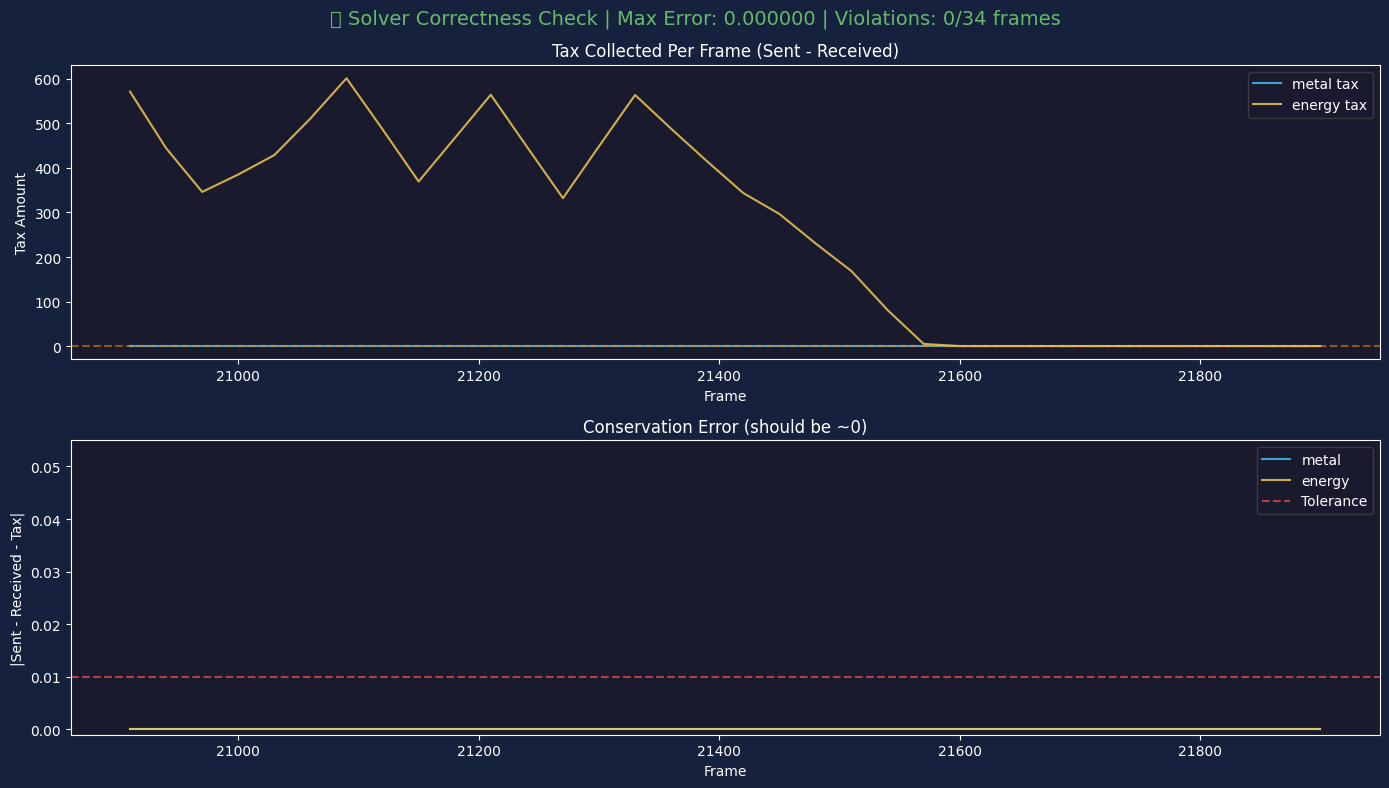

✅ SOLVER VERIFIED: Conservation law holds across all checked frames!


In [8]:
def check_solver_correctness(limit=1000):
    """Verify conservation law holds across frames."""
    
    output_df = query_df(f"""
        SELECT frame, resource, 
               SUM(sent) as total_sent, 
               SUM(received) as total_received
        FROM eco_team_output
        WHERE frame > (SELECT MAX(frame) FROM eco_team_output) - {limit}
        GROUP BY frame, resource
        ORDER BY frame
    """)
    
    if output_df.empty:
        print("No output data for correctness check")
        return
    
    output_df['tax'] = output_df['total_sent'] - output_df['total_received']
    output_df['balance_error'] = abs(output_df['total_sent'] - output_df['total_received'] - output_df['tax'])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.patch.set_facecolor('#16213e')
    for ax in axes:
        ax.set_facecolor('#1a1a2e')
        ax.tick_params(colors='white')
    
    for resource, color in [('metal', METAL_COLOR), ('energy', ENERGY_COLOR)]:
        rdf = output_df[output_df['resource'] == resource]
        if not rdf.empty:
            axes[0].plot(rdf['frame'], rdf['tax'], label=f'{resource} tax', color=color, alpha=0.8)
    axes[0].axhline(y=0, color='#ff9800', linestyle='--', alpha=0.5)
    axes[0].set_title('Tax Collected Per Frame (Sent - Received)', color='white')
    axes[0].set_xlabel('Frame', color='white')
    axes[0].set_ylabel('Tax Amount', color='white')
    axes[0].legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
    
    for resource, color in [('metal', METAL_COLOR), ('energy', ENERGY_COLOR)]:
        rdf = output_df[output_df['resource'] == resource]
        if not rdf.empty:
            axes[1].plot(rdf['frame'], rdf['balance_error'], label=resource, color=color, alpha=0.8)
    axes[1].axhline(y=0.01, color='#EF5350', linestyle='--', label='Tolerance', alpha=0.7)
    axes[1].set_title('Conservation Error (should be ~0)', color='white')
    axes[1].set_xlabel('Frame', color='white')
    axes[1].set_ylabel('|Sent - Received - Tax|', color='white')
    axes[1].legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
    axes[1].set_ylim(bottom=-0.001)
    
    max_error = output_df['balance_error'].max()
    violations = len(output_df[output_df['balance_error'] > 0.01])
    total_frames = len(output_df['frame'].unique())
    
    status_color = '#66BB6A' if violations == 0 else '#EF5350'
    fig.suptitle(f'🔬 Solver Correctness Check | Max Error: {max_error:.6f} | Violations: {violations}/{total_frames} frames', 
                color=status_color, fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    if violations == 0:
        print("✅ SOLVER VERIFIED: Conservation law holds across all checked frames!")
    else:
        print(f"⚠️ WARNING: Found {violations} frames with conservation violations > 0.01")

check_solver_correctness()


## 8. Interactive Frame Explorer
Use the slider below to scrub through frames and visualize the waterfill process in real-time.

In [9]:
# Load available frames for the slider
try:
    frames_df = query_df("SELECT DISTINCT frame FROM eco_team_waterfill ORDER BY frame")
    FRAMES = frames_df['frame'].tolist() if not frames_df.empty else []
except Exception as e:
    print(f"Error fetching frames: {e}")
    FRAMES = []

def update_view(frame_idx, resource='metal', ally_team=0):
    if not FRAMES:
        print("No frames available")
        return
        
    frame = FRAMES[frame_idx]
    
    print(f"🔍 Exploring Frame {frame} | {resource.upper()} | Alliance {ally_team}")
    print("=" * 60)
    
    fig = draw_waterfill_diagram(frame, resource, ally_team)
    if fig: plt.show()
    
    fig = verify_conservation(frame, resource)
    if fig: plt.show()
    
    frame_summary(frame, resource)

if FRAMES:
    max_frames = len(FRAMES) - 1
    
    style = {'description_width': 'initial'}
    
    frame_slider = widgets.IntSlider(
        value=max_frames,
        min=0,
        max=max_frames,
        step=1,
        description='Frame Index:',
        continuous_update=False,
        layout=widgets.Layout(width='90%'),
        style=style
    )
    
    resource_dropdown = widgets.Dropdown(
        options=['metal', 'energy'],
        value='metal',
        description='Resource:',
        style=style
    )
    
    ally_dropdown = widgets.Dropdown(
        options=list(range(10)),
        value=0,
        description='Alliance:',
        style=style
    )

    widgets.interact(update_view, 
                    frame_idx=frame_slider, 
                    resource=resource_dropdown, 
                    ally_team=ally_dropdown)
else:
    print("No data found in database. Please run parser.")


interactive(children=(IntSlider(value=306, continuous_update=False, description='Frame Index:', layout=Layout(…